Dataset carregado: (100000, 20)


,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411



Colunas: ['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID', 'ProductName', 'Category', 'Brand', 'Quantity', 'UnitPrice', 'Discount', 'Tax', 'ShippingCost', 'TotalAmount', 'PaymentMethod', 'OrderStatus', 'City', 'State', 'Country', 'SellerID']

Valores ausentes por coluna:
 OrderID          0
OrderDate        0
CustomerID       0
CustomerName     0
ProductID        0
ProductName      0
Category         0
Brand            0
Quantity         0
UnitPrice        0
Discount         0
Tax              0
ShippingCost     0
TotalAmount      0
PaymentMethod    0
OrderStatus      0
City             0
State            0
Country          0
SellerID         0
dtype: int64

Contagem OrderStatus:
 OrderStatus
Delivered    74628
Shipped      15192
Pending       4103
Returned      3049
Cancelled     3028
Name: count, dtype: int64

Estatísticas TotalAmount:
 count    100000.000000
mean        918.256479
std         724.508332
min           4.270000
25%         340.890000
50%         714

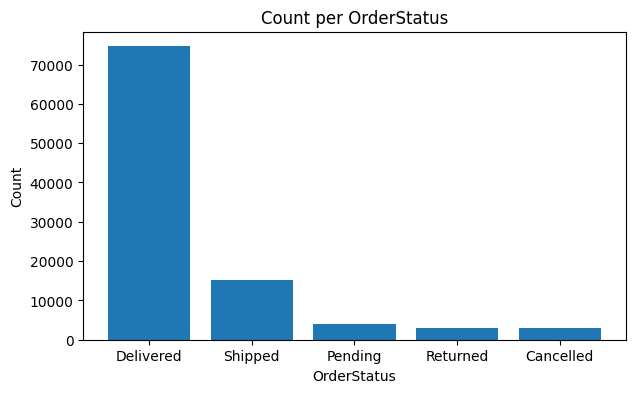

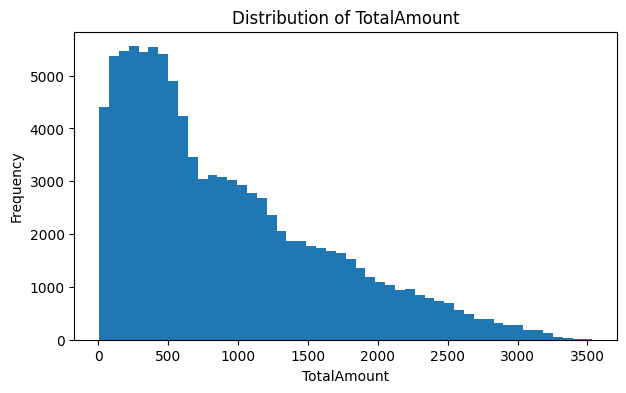


Após filtrar Delivered/Cancelled -> (77656, 20)
Distribuição classes:
 OrderStatus
Delivered    74628
Cancelled     3028
Name: count, dtype: int64

Numeric features: ['Quantity', 'UnitPrice', 'Discount', 'Tax', 'ShippingCost', 'TotalAmount']
Categorical candidates: ['Category', 'Brand', 'PaymentMethod', 'City', 'State', 'Country']
Category: 6 categorias (após top-k)
Brand: 10 categorias (após top-k)
PaymentMethod: 6 categorias (após top-k)
City: 11 categorias (após top-k)
State: 11 categorias (após top-k)
Country: 5 categorias (após top-k)

Train shape: (62124, 12) Test shape: (15532, 12)

Rodando GridSearch para Decision Tree...
DT best params: {'clf__max_depth': None, 'clf__min_samples_split': 10} CV score: 0.4996461961370822

Rodando GridSearch para KNN...


KeyboardInterrupt: 

In [7]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score, roc_auc_score, roc_curve)

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (7,4)


CSV_PATH = 'Amazon.csv'
TOP_K_CATEGORIES = 10
RANDOM_STATE = 42

def keep_top_k(series, k=10):
    """Agrupa categorias fora do top-k em 'Other'."""
    top = set(series.value_counts().nlargest(k).index)
    return series.apply(lambda x: x if x in top else 'Other')

def run_classification(csv_path=CSV_PATH, top_k=TOP_K_CATEGORIES, random_state=RANDOM_STATE):
    # --- Carregar dados ---
    df = pd.read_csv(csv_path)
    print("Dataset carregado:", df.shape)
    display(df.head())

    # --- EDA rápida ---
    print("\nColunas:", df.columns.tolist())
    print("\nValores ausentes por coluna:\n", df.isna().sum())
    print("\nContagem OrderStatus:\n", df['OrderStatus'].value_counts())
    print("\nEstatísticas TotalAmount:\n", df['TotalAmount'].describe())

    # Plots iniciais
    counts = df['OrderStatus'].value_counts()
    plt.bar(counts.index.astype(str), counts.values)
    plt.title('Count per OrderStatus')
    plt.ylabel('Count'); plt.xlabel('OrderStatus'); plt.show()

    plt.hist(df['TotalAmount'].dropna(), bins=50)
    plt.title('Distribution of TotalAmount'); plt.xlabel('TotalAmount'); plt.ylabel('Frequency'); plt.show()

    # --- Filtrar classes alvo (Delivered / Cancelled) ---
    y_all = df['OrderStatus'].fillna('Unknown')
    mask = y_all.isin(['Delivered', 'Cancelled'])
    df_model = df.loc[mask].copy()
    y = y_all.loc[mask].copy()
    print("\nApós filtrar Delivered/Cancelled ->", df_model.shape)
    print("Distribuição classes:\n", y.value_counts())

    # --- Seleção / limpeza de features ---
    drop_cols = ['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID', 'ProductName', 'SellerID']
    for c in drop_cols:
        if c in df_model.columns:
            df_model = df_model.drop(columns=c)

    numeric_features = [c for c in ['Quantity', 'UnitPrice', 'Discount', 'Tax', 'ShippingCost', 'TotalAmount'] if c in df_model.columns]
    cat_candidates = [c for c in ['Category', 'Brand', 'PaymentMethod', 'City', 'State', 'Country'] if c in df_model.columns]

    print("\nNumeric features:", numeric_features)
    print("Categorical candidates:", cat_candidates)

    # Agrupar top-k categorias
    for col in cat_candidates:
        df_model[col] = df_model[col].fillna('Unknown')
        df_model[col] = keep_top_k(df_model[col], k=top_k)
        print(f"{col}: {df_model[col].nunique()} categorias (após top-k)")

    X = df_model[numeric_features + cat_candidates].copy()

    # --- Split treino/teste ---
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20,
                                                        random_state=random_state, stratify=y)
    print("\nTrain shape:", X_train.shape, "Test shape:", X_test.shape)

    # --- Preprocessamento ---
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    # note: usar sparse_output=False para compatibilidade com sklearn >=1.4
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    preprocessor = ColumnTransformer(transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, cat_candidates)
    ])

    # --- Modelos e pipelines ---
    dt_pipeline = Pipeline([('preprocessor', preprocessor),
                            ('clf', DecisionTreeClassifier(random_state=random_state))])

    knn_pipeline = Pipeline([('preprocessor', preprocessor),
                             ('clf', KNeighborsClassifier())])

    # --- GridSearch (pequeno) ---
    dt_param_grid = {'clf__max_depth': [5, 10, None], 'clf__min_samples_split': [2, 10]}
    knn_param_grid = {'clf__n_neighbors': [3,5,7], 'clf__weights': ['uniform', 'distance']}

    cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=random_state)

    dt_search = GridSearchCV(dt_pipeline, dt_param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=0)
    knn_search = GridSearchCV(knn_pipeline, knn_param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=0)

    print("\nRodando GridSearch para Decision Tree...")
    try:
        dt_search.fit(X_train, y_train)
        print("DT best params:", dt_search.best_params_, "CV score:", dt_search.best_score_)
        dt_model = dt_search.best_estimator_
    except Exception as e:
        print("GridSearch DT falhou; ajustando pipeline sem busca:", e)
        dt_pipeline.fit(X_train, y_train)
        dt_model = dt_pipeline

    print("\nRodando GridSearch para KNN...")
    try:
        knn_search.fit(X_train, y_train)
        print("KNN best params:", knn_search.best_params_, "CV score:", knn_search.best_score_)
        knn_model = knn_search.best_estimator_
    except Exception as e:
        print("GridSearch KNN falhou; ajustando pipeline sem busca:", e)
        knn_pipeline.fit(X_train, y_train)
        knn_model = knn_pipeline

    models = {'DecisionTree': dt_model, 'KNN': knn_model}

    # --- Avaliação ---
    results = {}
    for name, model in models.items():
        print("\n\n===== Avaliando modelo:", name, "=====")
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, pos_label='Cancelled', average='binary', zero_division=0)
        rec = recall_score(y_test, y_pred, pos_label='Cancelled', average='binary', zero_division=0)
        f1 = f1_score(y_test, y_pred, pos_label='Cancelled', average='binary', zero_division=0)
        cm = confusion_matrix(y_test, y_pred, labels=['Delivered','Cancelled'])
        cls_report = classification_report(y_test, y_pred, digits=4, zero_division=0)

        print("Accuracy:", acc)
        print("Precision (Cancelled):", prec)
        print("Recall (Cancelled):", rec)
        print("F1 (Cancelled):", f1)
        print("Confusion Matrix (Delivered, Cancelled):\n", cm)
        print("\nClassification Report:\n", cls_report)

        # ROC-AUC (se disponível)
        roc_auc = None
        try:
            clf = model.named_steps['clf']
            pre = model.named_steps['preprocessor']
            if hasattr(clf, 'predict_proba'):
                X_test_trans = pre.transform(X_test)
                y_proba = clf.predict_proba(X_test_trans)
                class_index = list(clf.classes_).index('Cancelled')
                probs = y_proba[:, class_index]
                roc_auc = roc_auc_score((y_test=='Cancelled').astype(int), probs)
                fpr, tpr, _ = roc_curve((y_test=='Cancelled').astype(int), probs)
                plt.plot(fpr, tpr)
                plt.plot([0,1],[0,1], linestyle='--')
                plt.title(f'ROC curve - {name} (Cancelled positive)')
                plt.xlabel('FPR'); plt.ylabel('TPR')
                plt.show()
                print("ROC AUC:", roc_auc)
        except Exception as e:
            print("ROC não disponível/erro:", e)

        results[name] = {
            'model': model,
            'accuracy': acc,
            'precision_cancelled': prec,
            'recall_cancelled': rec,
            'f1_cancelled': f1,
            'confusion_matrix': cm,
            'classification_report': cls_report,
            'roc_auc': roc_auc
        }

    # --- Importâncias (Decision Tree, se existir) ---
    try:
        dt_est = models['DecisionTree']
        num_feats = numeric_features
        ohe = dt_est.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
        ohe_feats = ohe.get_feature_names_out(cat_candidates).tolist()
        feat_names = num_feats + ohe_feats
        importances = dt_est.named_steps['clf'].feature_importances_
        feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(20)
        print("\nTop features (Decision Tree):")
        display(feat_imp.to_frame('importance'))
    except Exception as e:
        print("Não foi possível extrair importâncias de features:", e)

    # Retornar dicionários úteis para uso posterior (ex.: geração de relatório separado)
    return {
        'dataframe': df,
        'X_train': X_train, 'X_test': X_test, 'y_train': y_train, 'y_test': y_test,
        'models': models, 'results': results,
        'numeric_features': numeric_features, 'categorical_features': cat_candidates
    }

# Executar
outputs = run_classification()
